# E-Commerce Sales & Customer Analytics

### Data Analyst Portfolio Project

**Objective:**  
Analyze two years of e-commerce transaction data to identify sales trends,
profitability drivers, customer behavior, product performance, and the
root causes of sales declines.

### Key Business Areas
- Sales & Revenue Performance
- Profitability Analysis
- Customer Segmentation
- Product Performance
- Geographic Analysis
- Root-Cause Analysis
- Business Recommendations

## 1. Business Problem

The company wants to understand its sales performance, customer behavior,
product profitability, and geographic performance across a two-year period.

The analysis will answer the following business questions:

1. How are sales and profit performing over time?
2. Which months and categories drive sales?
3. What caused significant sales declines?
4. Which customer segments generate the most revenue?
5. Which customers are most valuable to the business?
6. Which products generate the most sales and profit?
7. Which products represent growth opportunities?
8. Which cities perform best?
9. Where is the company losing sales?
10. What actions should management take based on the findings?

## 2. Analysis Approach

The project follows a structured business analytics process:

**Data → Cleaning → Exploration → KPI Analysis → Root-Cause Analysis
→ Customer Segmentation → Product Analysis → Geographic Analysis
→ Business Recommendations**

## 3. Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
df = pd.read_csv("shopsphere_ecommerce_200k.csv")


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (200000, 24)


In [5]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product_ID,Product_Name,Brand,Category,Quantity,Unit_Price,Discount,Revenue,Discount_Amount,Final_Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Shipping_Days,Rating
0,ORD0047997,2024-01-01,44736,Karan Shah,34,Female,Hyderabad,97,Product_097,UrbanX,Books,1,610.50,0.04,610.50,25.03,585.47,379.20,206.27,0.35,UPI,Delivered,6,5
1,ORD0092772,2024-01-01,1102,Neha Shah,38,Female,Ahmedabad,119,Product_119,Zen,Home & Kitchen,1,"12,097.46",0.11,"12,097.46","1,318.62","10,778.84","6,645.86","4,132.98",0.38,Debit Card,Delivered,2,5
2,ORD0040156,2024-01-01,14418,Kavya Iyer,44,Male,Indore,378,Product_378,Prime,Home & Kitchen,1,"17,371.71",0.02,"17,371.71",364.81,"17,006.90","10,710.35","6,296.55",0.37,Net Banking,Cancelled,1,5
3,ORD0121876,2024-01-01,34469,Vivaan Singh,26,Male,Kolkata,193,Product_193,Astra,Home & Kitchen,3,"4,936.81",0.13,"14,810.43","1,895.74","12,914.69","9,030.44","3,884.26",0.30,Credit Card,Delivered,8,5
4,ORD0108725,2024-01-01,49522,Sneha Verma,55,Female,Hyderabad,496,Product_496,Astra,Home & Kitchen,4,"20,457.33",0.11,"81,829.32","9,083.05","72,746.27","53,915.33","18,830.94",0.26,Cash on Delivery,Cancelled,7,4


In [6]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product_ID', 'Product_Name', 'Brand', 'Category', 'Quantity', 'Unit_Price', 'Discount', 'Revenue', 'Discount_Amount', 'Final_Sales', 'Cost', 'Profit', 'Profit_Margin', 'Payment_Method', 'Order_Status', 'Shipping_Days', 'Rating']


## 4. Data Understanding

The dataset contains 200,000 e-commerce transactions and 24 attributes
covering orders, customers, products, financial performance, payments,
shipping, order status, and customer ratings.

### Main Data Categories

- **Order Information:** Order_ID, Order_Date, Order_Status
- **Customer Information:** Customer_ID, Customer_Name, Age, Gender, City
- **Product Information:** Product_ID, Product_Name, Brand, Category
- **Sales Information:** Quantity, Unit_Price, Revenue, Discount,
  Discount_Amount, Final_Sales
- **Profitability:** Cost, Profit, Profit_Margin
- **Operations:** Payment_Method, Shipping_Days
- **Customer Experience:** Rating

In [7]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product_ID,Product_Name,Brand,Category,Quantity,Unit_Price,Discount,Revenue,Discount_Amount,Final_Sales,Cost,Profit,Profit_Margin,Payment_Method,Order_Status,Shipping_Days,Rating
0,ORD0047997,2024-01-01,44736,Karan Shah,34,Female,Hyderabad,97,Product_097,UrbanX,Books,1,610.50,0.04,610.50,25.03,585.47,379.20,206.27,0.35,UPI,Delivered,6,5
1,ORD0092772,2024-01-01,1102,Neha Shah,38,Female,Ahmedabad,119,Product_119,Zen,Home & Kitchen,1,"12,097.46",0.11,"12,097.46","1,318.62","10,778.84","6,645.86","4,132.98",0.38,Debit Card,Delivered,2,5
2,ORD0040156,2024-01-01,14418,Kavya Iyer,44,Male,Indore,378,Product_378,Prime,Home & Kitchen,1,"17,371.71",0.02,"17,371.71",364.81,"17,006.90","10,710.35","6,296.55",0.37,Net Banking,Cancelled,1,5
3,ORD0121876,2024-01-01,34469,Vivaan Singh,26,Male,Kolkata,193,Product_193,Astra,Home & Kitchen,3,"4,936.81",0.13,"14,810.43","1,895.74","12,914.69","9,030.44","3,884.26",0.30,Credit Card,Delivered,8,5
4,ORD0108725,2024-01-01,49522,Sneha Verma,55,Female,Hyderabad,496,Product_496,Astra,Home & Kitchen,4,"20,457.33",0.11,"81,829.32","9,083.05","72,746.27","53,915.33","18,830.94",0.26,Cash on Delivery,Cancelled,7,4


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  str    
 1   Order_Date       200000 non-null  str    
 2   Customer_ID      200000 non-null  int64  
 3   Customer_Name    200000 non-null  str    
 4   Age              200000 non-null  int64  
 5   Gender           200000 non-null  str    
 6   City             200000 non-null  str    
 7   Product_ID       200000 non-null  int64  
 8   Product_Name     200000 non-null  str    
 9   Brand            200000 non-null  str    
 10  Category         200000 non-null  str    
 11  Quantity         200000 non-null  int64  
 12  Unit_Price       200000 non-null  float64
 13  Discount         200000 non-null  float64
 14  Revenue          200000 non-null  float64
 15  Discount_Amount  200000 non-null  float64
 16  Final_Sales      200000 non-null  float64
 17  Co

In [8]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

### Duplicate Records

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
print("Unique Orders:", df["Order_ID"].nunique())
print("Total Rows:", len(df))

Unique Orders: 200000
Total Rows: 200000


## 5. Data Cleaning & Preparation

The initial data-quality checks show:

- No missing values
- No duplicate rows
- 200,000 unique orders
- Order_Date is stored as a string and needs conversion to datetime

The main preparation step is therefore converting the order date into
a proper datetime format and creating useful time-based features.

In [11]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [12]:
df["Order_Date"].dtype

dtype('<M8[us]')

In [13]:
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()

In [14]:
df[
    [
        "Order_Date",
        "Order_Year",
        "Order_Month",
        "Month_Name"
    ]
].head(10)

,Order_Date,Order_Year,Order_Month,Month_Name
0,2024-01-01,2024,1,January
1,2024-01-01,2024,1,January
2,2024-01-01,2024,1,January
3,2024-01-01,2024,1,January
4,2024-01-01,2024,1,January
5,2024-01-01,2024,1,January
6,2024-01-01,2024,1,January
7,2024-01-01,2024,1,January
8,2024-01-01,2024,1,January
9,2024-01-01,2024,1,January


In [15]:
print("Minimum Order Date:", df["Order_Date"].min())
print("Maximum Order Date:", df["Order_Date"].max())

Minimum Order Date: 2024-01-01 00:00:00
Maximum Order Date: 2025-12-31 00:00:00


## 6. Executive KPIs

The following KPIs provide a high-level overview of business performance
across the two-year period.

In [16]:
total_sales = df["Final_Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()

average_order_value = total_sales / total_orders

profit_margin = (
    total_profit / total_sales
) * 100

print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

Total Sales: ₹4,109,890,831.08
Total Profit: ₹1,232,649,816.58
Total Orders: 200,000
Total Customers: 49,054
Average Order Value: ₹20,549.45
Profit Margin: 29.99%


## 7. Sales Performance Over Time

### 7.1 Year-over-Year Sales Performance

Compare total sales between 2024 and 2025 to determine whether the
business grew or declined year over year.

In [17]:
annual_sales = (
    df.groupby("Order_Year")["Final_Sales"]
      .sum()
)

annual_sales

Order_Year
2024   2,062,503,335.40
2025   2,047,387,495.68
Name: Final_Sales, dtype: float64

In [18]:
yoy_growth = (
    (annual_sales[2025] - annual_sales[2024])
    / annual_sales[2024]
) * 100

print(f"2025 YoY Sales Growth: {yoy_growth:.2f}%")

2025 YoY Sales Growth: -0.73%


### Key Finding

Total sales declined by approximately **0.73% in 2025 compared with 2024**.

Although the overall decline is relatively small, further analysis is required
to identify which months, categories, products, and locations contributed to
the decline.

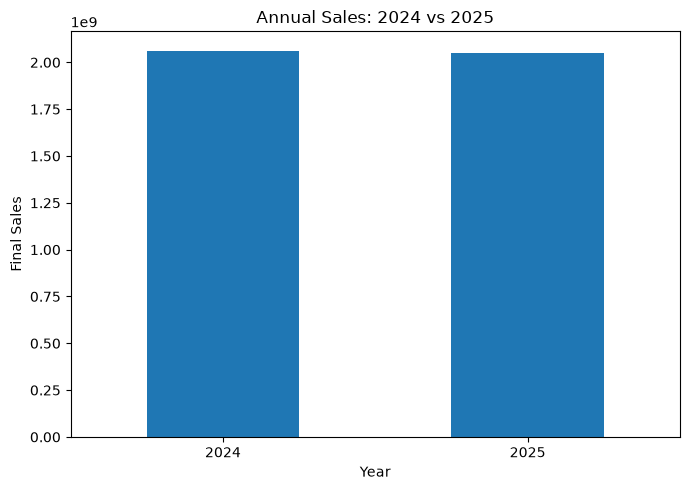

In [19]:
annual_sales.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Annual Sales: 2024 vs 2025")
plt.xlabel("Year")
plt.ylabel("Final Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 7.2 Monthly Sales Trend

Analyze monthly sales across 2024 and 2025 to identify seasonal patterns
and months with significant year-over-year changes.

In [20]:
monthly_sales = (
    df.groupby(["Order_Year", "Order_Month"])["Final_Sales"]
      .sum()
      .reset_index()
)

monthly_sales

,Order_Year,Order_Month,Final_Sales
0,2024,1,"172,213,381.17"
1,2024,2,"161,984,628.60"
2,2024,3,"179,865,345.20"
3,2024,4,"169,111,760.69"
4,2024,5,"172,588,202.50"
5,2024,6,"167,788,207.28"
6,2024,7,"177,016,764.24"
7,2024,8,"173,727,831.85"
8,2024,9,"174,782,358.93"
9,2024,10,"174,324,332.54"


In [22]:
monthly_comparison = (
    monthly_sales
    .pivot(
        index="Order_Month",
        columns="Order_Year",
        values="Final_Sales"
    )
)

monthly_comparison

Order_Year,2024,2025
Order_Month,,
1,"172,213,381.17","170,655,477.45"
2,"161,984,628.60","152,773,661.46"
3,"179,865,345.20","174,638,533.58"
4,"169,111,760.69","170,216,799.66"
5,"172,588,202.50","178,524,218.47"
6,"167,788,207.28","167,305,387.04"
7,"177,016,764.24","177,169,524.82"
8,"173,727,831.85","175,363,304.80"
9,"174,782,358.93","166,295,379.78"


In [23]:
monthly_comparison["YoY_Change_%"] = (
    (
        monthly_comparison[2025]
        - monthly_comparison[2024]
    )
    / monthly_comparison[2024]
) * 100

monthly_comparison

Order_Year,2024,2025,YoY_Change_%
Order_Month,,,
1,"172,213,381.17","170,655,477.45",-0.90
2,"161,984,628.60","152,773,661.46",-5.69
3,"179,865,345.20","174,638,533.58",-2.91
4,"169,111,760.69","170,216,799.66",0.65
5,"172,588,202.50","178,524,218.47",3.44
6,"167,788,207.28","167,305,387.04",-0.29
7,"177,016,764.24","177,169,524.82",0.09
8,"173,727,831.85","175,363,304.80",0.94
9,"174,782,358.93","166,295,379.78",-4.86


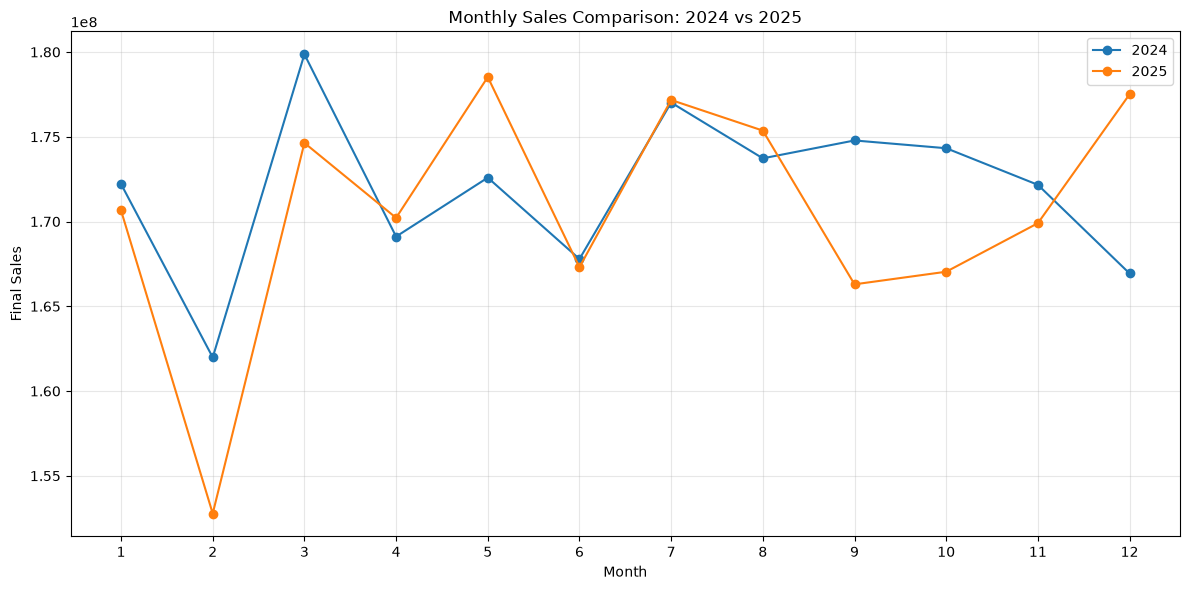

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_comparison.index,
    monthly_comparison[2024],
    marker="o",
    label="2024"
)

plt.plot(
    monthly_comparison.index,
    monthly_comparison[2025],
    marker="o",
    label="2025"
)

plt.title("Monthly Sales Comparison: 2024 vs 2025")
plt.xlabel("Month")
plt.ylabel("Final Sales")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
monthly_comparison["Sales_Change"] = (
    monthly_comparison[2025]
    - monthly_comparison[2024]
)

In [26]:
monthly_comparison.sort_values(
    "Sales_Change"
).head(5)

Order_Year,2024,2025,YoY_Change_%,Sales_Change
Order_Month,,,,
2,"161,984,628.60","152,773,661.46",-5.69,"-9,210,967.14"
9,"174,782,358.93","166,295,379.78",-4.86,"-8,486,979.15"
10,"174,324,332.54","167,038,445.74",-4.18,"-7,285,886.80"
3,"179,865,345.20","174,638,533.58",-2.91,"-5,226,811.62"
11,"172,164,605.04","169,901,965.64",-1.31,"-2,262,639.40"


### 7.3 Root-Cause Analysis — February 2025

February 2025 recorded the largest year-over-year sales decline in absolute
terms. We will drill down by product category to identify which categories
contributed most to the decline.

In [27]:
february_sales = (
    df[df["Order_Month"] == 2]
    .groupby("Order_Year")["Final_Sales"]
    .sum()
)

february_sales

Order_Year
2024   161,984,628.60
2025   152,773,661.46
Name: Final_Sales, dtype: float64

In [28]:
feb_category = (
    df[df["Order_Month"] == 2]
    .groupby(["Category", "Order_Year"])["Final_Sales"]
    .sum()
    .reset_index()
)

feb_category

,Category,Order_Year,Final_Sales
0,Beauty,2024,"4,916,303.67"
1,Beauty,2025,"4,918,995.86"
2,Books,2024,"2,728,998.90"
3,Books,2025,"2,592,141.11"
4,Electronics,2024,"112,655,393.43"
5,Electronics,2025,"104,980,351.54"
6,Fashion,2024,"10,208,510.62"
7,Fashion,2025,"10,116,562.87"
8,Home & Kitchen,2024,"24,203,505.57"
9,Home & Kitchen,2025,"23,042,975.33"


In [29]:
feb_category_comparison = (
    feb_category
    .pivot(
        index="Category",
        columns="Order_Year",
        values="Final_Sales"
    )
    .fillna(0)
)

feb_category_comparison["Sales_Change"] = (
    feb_category_comparison[2025]
    - feb_category_comparison[2024]
)

feb_category_comparison["YoY_Change_%"] = (
    feb_category_comparison["Sales_Change"]
    / feb_category_comparison[2024]
) * 100

feb_category_comparison.sort_values(
    "Sales_Change"
)

Order_Year,2024,2025,Sales_Change,YoY_Change_%
Category,,,,
Electronics,"112,655,393.43","104,980,351.54","-7,675,041.89",-6.81
Home & Kitchen,"24,203,505.57","23,042,975.33","-1,160,530.24",-4.79
Sports,"7,271,916.41","7,122,634.76","-149,281.65",-2.05
Books,"2,728,998.90","2,592,141.11","-136,857.80",-5.01
Fashion,"10,208,510.62","10,116,562.87","-91,947.74",-0.90
Beauty,"4,916,303.67","4,918,995.86","2,692.19",0.05


### February 2025 Root-Cause Finding

February 2025 experienced the largest absolute year-over-year sales decline.

Category-level analysis shows that Electronics was the primary contributor,
with sales declining by approximately ₹7.68M (-6.81%) compared with February
2024.

Home & Kitchen was the second-largest contributor to the decline, decreasing
by approximately ₹1.16M (-4.79%).

Electronics therefore requires further investigation to understand whether
the decline was driven by changes in orders, customers, quantity, average
order value, or discounting.

### 7.4 Electronics Root-Cause Analysis

In [30]:
electronics_feb = df[
    (df["Order_Month"] == 2) &
    (df["Category"] == "Electronics")
]

electronics_feb_analysis = (
    electronics_feb
    .groupby("Order_Year")
    .agg(
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique"),
        Quantity=("Quantity", "sum"),
        Sales=("Final_Sales", "sum"),
        Avg_Discount=("Discount", "mean")
    )
)

electronics_feb_analysis

,Orders,Customers,Quantity,Sales,Avg_Discount
Order_Year,,,,,
2024,1809,1779,3442,"112,655,393.43",0.10
2025,1699,1672,3198,"104,980,351.54",0.10


In [31]:
electronics_feb_analysis["AOV"] = (
    electronics_feb_analysis["Sales"]
    / electronics_feb_analysis["Orders"]
)

electronics_feb_analysis

,Orders,Customers,Quantity,Sales,Avg_Discount,AOV
Order_Year,,,,,,
2024,1809,1779,3442,"112,655,393.43",0.10,"62,274.95"
2025,1699,1672,3198,"104,980,351.54",0.10,"61,789.49"


In [32]:
electronics_change = (
    (
        electronics_feb_analysis.loc[2025]
        - electronics_feb_analysis.loc[2024]
    )
    / electronics_feb_analysis.loc[2024]
) * 100

electronics_change

Orders         -6.08
Customers      -6.01
Quantity       -7.09
Sales          -6.81
Avg_Discount    3.44
AOV            -0.78
dtype: float64

### Electronics Root-Cause Finding

Electronics sales declined by **6.81%** in February 2025 compared with
February 2024.

The decline was accompanied by:

- **6.08% fewer orders**
- **6.01% fewer customers**
- **7.09% lower quantity sold**
- Only **0.78% lower AOV**
- **3.44% higher average discount**

The results indicate that the February Electronics decline was primarily
associated with lower customer and order volume and fewer units sold,
rather than a major reduction in average order value.

Higher discounting occurred during the decline, but the analysis does not
establish that discounting caused the sales decline.

### 7.5 Electronics Decline by City

Analyze February Electronics sales by city to identify geographic areas
with the largest year-over-year declines.

In [33]:
electronics_city = (
    df[
        (df["Order_Month"] == 2) &
        (df["Category"] == "Electronics")
    ]
    .groupby(["City", "Order_Year"])
    .agg(
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique"),
        Quantity=("Quantity", "sum"),
        Sales=("Final_Sales", "sum")
    )
    .reset_index()
)

In [34]:
electronics_city_sales = (
    electronics_city
    .pivot_table(
        index="City",
        columns="Order_Year",
        values="Sales",
        fill_value=0
    )
    .reset_index()
)

electronics_city_sales["Sales_Change_%"] = (
    (
        electronics_city_sales[2025]
        - electronics_city_sales[2024]
    )
    / electronics_city_sales[2024]
) * 100

electronics_city_sales.sort_values(
    "Sales_Change_%"
).head(10)

Order_Year,City,2024,2025,Sales_Change_%
12,Pune,"8,224,997.15","5,394,785.04",-34.41
5,Indore,"7,535,908.13","5,220,004.19",-30.73
13,Surat,"8,473,575.32","6,943,209.51",-18.06
4,Hyderabad,"8,094,720.93","6,646,508.72",-17.89
0,Ahmedabad,"8,588,060.41","7,246,612.47",-15.62
7,Kolkata,"8,355,664.52","7,506,401.11",-10.16
1,Bengaluru,"7,591,790.65","6,985,336.15",-7.99
9,Mumbai,"7,554,247.31","7,150,536.99",-5.34
14,Thane,"7,413,690.09","7,022,563.04",-5.28
8,Lucknow,"7,812,191.74","7,497,367.45",-4.03


### 7.6 Pune Electronics Decline — Product-Level Analysis

Pune recorded the largest decline in February Electronics sales, falling
34.41% year over year.

The next step is to identify which products contributed to this decline.

In [35]:
pune_electronics = df[
    (df["Order_Month"] == 2) &
    (df["Category"] == "Electronics") &
    (df["City"] == "Pune")
]

pune_products = (
    pune_electronics
    .groupby(["Product_ID", "Product_Name", "Order_Year"])
    .agg(
        Orders=("Order_ID", "nunique"),
        Quantity=("Quantity", "sum"),
        Sales=("Final_Sales", "sum")
    )
    .reset_index()
)

In [36]:
pune_product_sales = (
    pune_products
    .pivot_table(
        index=["Product_ID", "Product_Name"],
        columns="Order_Year",
        values="Sales",
        fill_value=0
    )
    .reset_index()
)

In [37]:
pune_product_sales["Sales_Change"] = (
    pune_product_sales[2025]
    - pune_product_sales[2024]
)

pune_product_sales["Sales_Change_%"] = (
    pune_product_sales["Sales_Change"]
    / pune_product_sales[2024]
) * 100

In [38]:
lost_products = pune_product_sales[
    (pune_product_sales[2024] > 0) &
    (pune_product_sales[2025] == 0)
]

lost_products.sort_values(
    2024,
    ascending=False
).head(10)

Order_Year,Product_ID,Product_Name,2024,2025,Sales_Change,Sales_Change_%
65,330,Product_330,"570,039.24",0.00,"-570,039.24",-100.00
44,226,Product_226,"395,296.78",0.00,"-395,296.78",-100.00
45,229,Product_229,"321,779.31",0.00,"-321,779.31",-100.00
19,72,Product_072,"258,192.10",0.00,"-258,192.10",-100.00
94,482,Product_482,"242,194.62",0.00,"-242,194.62",-100.00
79,407,Product_407,"215,900.10",0.00,"-215,900.10",-100.00
59,293,Product_293,"214,776.90",0.00,"-214,776.90",-100.00
51,259,Product_259,"212,349.83",0.00,"-212,349.83",-100.00
24,111,Product_111,"208,688.42",0.00,"-208,688.42",-100.00
82,417,Product_417,"196,323.86",0.00,"-196,323.86",-100.00


In [39]:
top_10_lost_sales = (
    lost_products
    .sort_values(2024, ascending=False)
    .head(10)[2024]
    .sum()
)

pune_decline = (
    pune_product_sales[2025].sum()
    - pune_product_sales[2024].sum()
)

print("Top 10 Lost Product Sales:", top_10_lost_sales)
print("Pune Net Sales Decline:", pune_decline)
print(
    "Top 10 Lost Product Sales / Net Decline:",
    (top_10_lost_sales / abs(pune_decline)) * 100,
    "%"
)

Top 10 Lost Product Sales: 2835541.16111
Pune Net Sales Decline: -2830212.1067900006
Top 10 Lost Product Sales / Net Decline: 100.18829169401171 %


### Pune Electronics — Product-Level Finding

The top 10 products that had sales in February 2024 but zero sales in
February 2025 accounted for approximately **₹2.84M** in prior-year sales.

Pune Electronics experienced a net sales decline of approximately
**₹2.83M** during the same period.

The lost sales from these products were approximately **100.19% of the
net decline**, indicating that growth from other products partially
offset the revenue lost from these discontinued/inactive products.

This analysis identifies product-level sales disappearance as a key area
requiring business investigation. However, the available transaction
data does not establish whether the products were discontinued,
out-of-stock, unavailable, or affected by another operational factor.

## 8. Customer Analysis

Customer analysis evaluates customer purchasing behavior, repeat
purchases, customer value, and revenue contribution.

The objective is to identify high-value customers and opportunities
to improve customer retention and lifetime value.

### 8.1 Customer Purchase Frequency

In [40]:
customer_orders = (
    df.groupby("Customer_ID")["Order_ID"]
      .nunique()
)

customer_type = pd.DataFrame({
    "Orders": customer_orders
})

customer_type["Customer_Type"] = np.where(
    customer_type["Orders"] == 1,
    "One-Time",
    "Repeat"
)

customer_type["Customer_Type"].value_counts()

Customer_Type
Repeat      45377
One-Time     3677
Name: count, dtype: int64

In [41]:
customer_type["Customer_Type"].value_counts(
    normalize=True
) * 100

Customer_Type
Repeat     92.50
One-Time    7.50
Name: proportion, dtype: float64

### 8.1 Customer Purchase Frequency — Key Finding

The customer base is highly repeat-oriented:

- **92.50%** of customers are repeat customers.
- **7.50%** of customers are one-time customers.

This indicates strong repeat-purchase behavior. However, the 7.50% of
one-time customers represent a potential retention opportunity.
Further analysis is required to determine how much revenue is generated
by each customer group.

### 8.2 Revenue Contribution by Customer Type

In [42]:
customer_revenue = (
    df.groupby("Customer_ID")
      .agg(
          Orders=("Order_ID", "nunique"),
          Total_Sales=("Final_Sales", "sum")
      )
)

customer_revenue["Customer_Type"] = np.where(
    customer_revenue["Orders"] == 1,
    "One-Time",
    "Repeat"
)

customer_type_summary = (
    customer_revenue
    .groupby("Customer_Type")
    .agg(
        Customers=("Orders", "count"),
        Total_Sales=("Total_Sales", "sum"),
        Avg_Customer_Sales=("Total_Sales", "mean")
    )
)

customer_type_summary

,Customers,Total_Sales,Avg_Customer_Sales
Customer_Type,,,
One-Time,3677,"78,115,506.64","21,244.36"
Repeat,45377,"4,031,775,324.44","88,850.64"


In [43]:
customer_type_summary["Revenue_Share_%"] = (
    customer_type_summary["Total_Sales"]
    / customer_type_summary["Total_Sales"].sum()
) * 100

customer_type_summary

,Customers,Total_Sales,Avg_Customer_Sales,Revenue_Share_%
Customer_Type,,,,
One-Time,3677,"78,115,506.64","21,244.36",1.90
Repeat,45377,"4,031,775,324.44","88,850.64",98.10


### Key Finding

Repeat customers are the primary revenue driver for the business.

- Repeat customers represent **92.50%** of the customer base.
- They generate **98.10% of total sales**.
- One-time customers represent **7.50%** of customers but contribute only
  **1.90% of sales**.
- Average sales per repeat customer are approximately **4.18× higher** than
  average sales per one-time customer.

### Business Implication

Customer retention should be a major business priority because repeat
customers contribute the overwhelming majority of revenue.

The one-time customer segment also represents a potential opportunity:
converting a portion of these customers into repeat buyers could increase
customer lifetime value and future revenue.

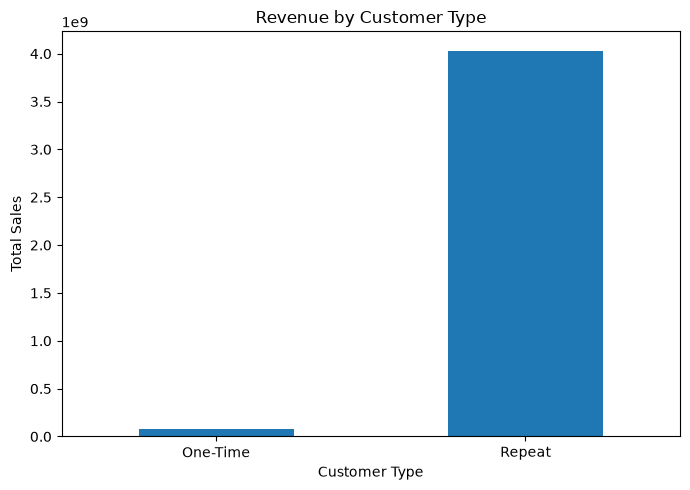

In [44]:
customer_type_summary["Total_Sales"].plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.3 High-Value Customers

In [45]:
top_customers = (
    customer_revenue
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_customers

,Orders,Total_Sales,Customer_Type
Customer_ID,,,
42364,10,"803,753.68",Repeat
11803,8,"713,108.88",Repeat
27830,7,"691,470.31",Repeat
32813,9,"650,518.97",Repeat
2155,7,"648,274.54",Repeat
2882,11,"648,274.21",Repeat
47260,9,"642,071.31",Repeat
14901,7,"633,989.85",Repeat
35376,10,"633,117.27",Repeat


### 8.4 Customer Revenue Concentration

Determine what percentage of total revenue is generated by the top 10
customers to assess customer concentration risk.

In [46]:
top_10_sales = top_customers["Total_Sales"].sum()

total_customer_sales = customer_revenue["Total_Sales"].sum()

top_10_revenue_share = (
    top_10_sales / total_customer_sales
) * 100

print(f"Top 10 Customer Sales: ₹{top_10_sales:,.2f}")
print(f"Top 10 Revenue Share: {top_10_revenue_share:.2f}%")

Top 10 Customer Sales: ₹6,687,745.31
Top 10 Revenue Share: 0.16%


### Customer Concentration — Key Finding

The top 10 customers generated approximately **₹6.69M**, representing only
**0.16% of total sales**.

This indicates that revenue is highly diversified across the customer base
and the business is not materially dependent on a small number of individual
customers.

Combined with the **98.10% revenue contribution from repeat customers**, the
business appears to rely on a broad base of repeat customers rather than a
small group of high-value individuals.

## 9. RFM Customer Segmentation

RFM analysis segments customers based on:

- **Recency:** Days since the customer's most recent purchase
- **Frequency:** Number of orders placed
- **Monetary:** Total sales generated

The objective is to identify high-value customers, loyal customers,
potential loyalists, new customers, and customers at risk of becoming
inactive.

In [47]:
analysis_date = df["Order_Date"].max() + pd.Timedelta(days=1)

print("Analysis Date:", analysis_date)

Analysis Date: 2026-01-01 00:00:00


In [48]:
rfm = (
    df.groupby("Customer_ID")
      .agg(
          Recency=(
              "Order_Date",
              lambda x: (analysis_date - x.max()).days
          ),
          Frequency=("Order_ID", "nunique"),
          Monetary=("Final_Sales", "sum")
      )
      .reset_index()
)

rfm.head()

,Customer_ID,Recency,Frequency,Monetary
0,1,590,1,"25,829.24"
1,2,332,2,"16,677.37"
2,3,359,4,"43,440.98"
3,4,93,3,"145,187.70"
4,5,27,3,"11,504.17"


In [49]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,"49,054.00","49,054.00","49,054.00"
mean,169.13,4.08,"83,782.99"
std,152.18,1.94,"82,242.07"
min,1.00,1.00,143.68
25%,52.00,3.00,"23,800.77"
50%,123.00,4.00,"57,661.42"
75%,243.00,5.00,"117,828.69"
max,731.00,14.00,"803,753.68"


In [50]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
)

In [51]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [52]:
rfm["RFM_Score"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

In [53]:
rfm.head(10)

,Customer_ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,1,590,1,"25,829.24",1,1,2,4
1,2,332,2,"16,677.37",1,1,1,3
2,3,359,4,"43,440.98",1,3,3,7
3,4,93,3,"145,187.70",3,2,5,10
4,5,27,3,"11,504.17",5,2,1,8
5,6,14,5,"58,373.23",5,4,3,12
6,7,175,7,"170,676.31",2,5,5,12
7,8,174,2,"11,259.03",2,1,1,4
8,9,157,8,"95,175.60",3,5,4,12
9,10,68,5,"87,763.29",4,4,4,12


In [54]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
3     2701
4     2613
5     3117
6     3717
7     4429
8     4702
9     4929
10    5111
11    5031
12    4780
13    3857
14    2710
15    1357
Name: count, dtype: int64

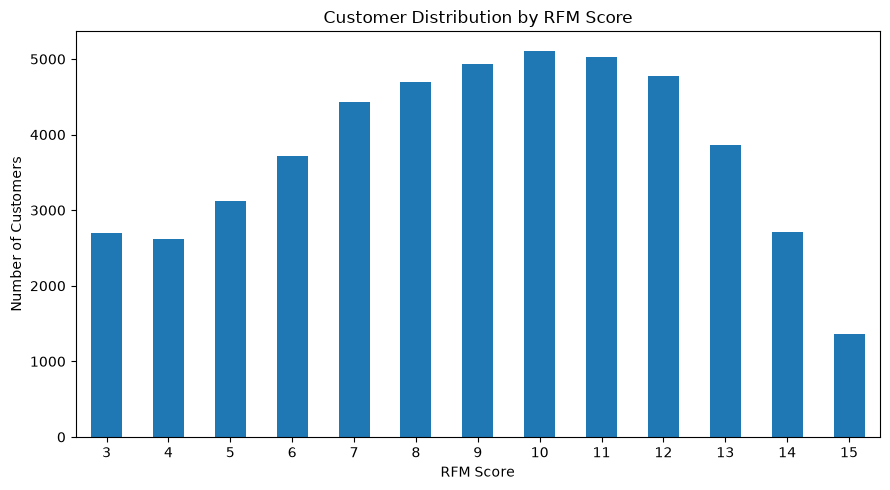

In [55]:
rfm["RFM_Score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Distribution by RFM Score")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9.1 Customer Segmentation

Customers are classified into business segments using their RFM scores.

The segmentation helps identify customers who should be retained,
developed, reactivated, or targeted for new-customer conversion.

In [56]:
def segment_customer(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f >= 2 and m >= 2:
        return "Potential Loyalists"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2:
        return "Hibernating"

    elif r >= 4 and f <= 2:
        return "New Customers"

    else:
        return "Others"


rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [57]:
rfm["Segment"].value_counts()

Segment
Hibernating            11298
Others                  9120
Potential Loyalists     7183
Champions               6725
Loyal Customers         6041
At Risk                 5955
New Customers           2732
Name: count, dtype: int64

### 9.2 Customer Segment Performance

Analyze the number of customers, total sales, average customer value,
recency, and frequency for each RFM segment.

In [58]:
segment_summary = (
    rfm.groupby("Segment")
       .agg(
           Customers=("Customer_ID", "count"),
           Total_Sales=("Monetary", "sum"),
           Avg_Sales=("Monetary", "mean"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean")
       )
       .sort_values("Total_Sales", ascending=False)
)

segment_summary

,Customers,Total_Sales,Avg_Sales,Avg_Recency,Avg_Frequency
Segment,,,,,
Champions,6725,"1,159,594,364.34","172,430.39",41.11,6.45
At Risk,5955,"758,838,933.18","127,428.87",262.39,5.01
Loyal Customers,6041,"668,520,171.00","110,663.83",92.15,5.99
Potential Loyalists,7183,"532,571,571.82","74,143.33",42.51,3.93
Hibernating,11298,"479,366,041.90","42,429.28",358.36,2.11
Others,9120,"430,621,297.48","47,217.25",156.29,3.61
New Customers,2732,"80,378,451.36","29,421.10",44.34,2.09


In [59]:
segment_summary["Revenue_Share_%"] = (
    segment_summary["Total_Sales"]
    / segment_summary["Total_Sales"].sum()
) * 100

segment_summary

,Customers,Total_Sales,Avg_Sales,Avg_Recency,Avg_Frequency,Revenue_Share_%
Segment,,,,,,
Champions,6725,"1,159,594,364.34","172,430.39",41.11,6.45,28.21
At Risk,5955,"758,838,933.18","127,428.87",262.39,5.01,18.46
Loyal Customers,6041,"668,520,171.00","110,663.83",92.15,5.99,16.27
Potential Loyalists,7183,"532,571,571.82","74,143.33",42.51,3.93,12.96
Hibernating,11298,"479,366,041.90","42,429.28",358.36,2.11,11.66
Others,9120,"430,621,297.48","47,217.25",156.29,3.61,10.48
New Customers,2732,"80,378,451.36","29,421.10",44.34,2.09,1.96


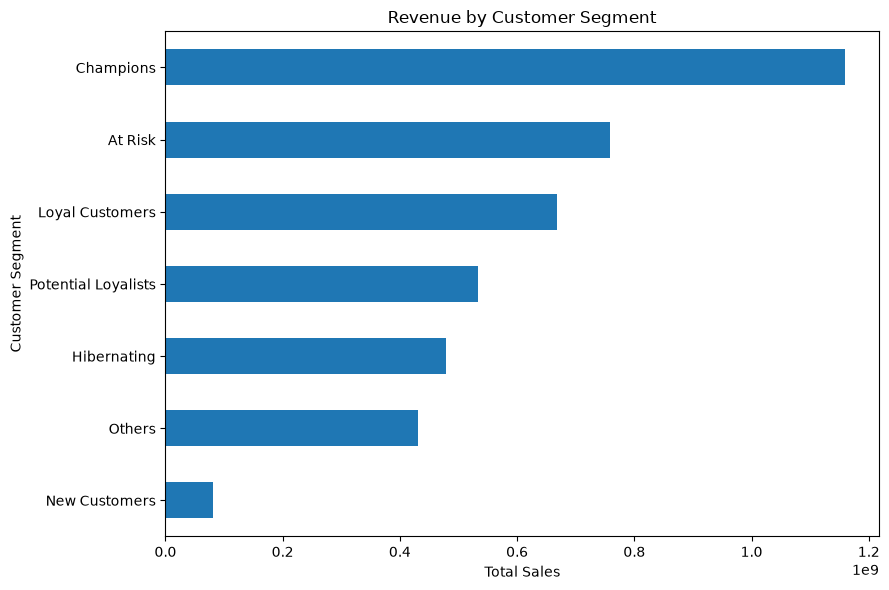

In [60]:
segment_summary["Total_Sales"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Total Sales")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

### RFM Segment Findings

RFM analysis reveals several important customer opportunities.

**Champions** are the highest-value segment, generating ₹1.16B in sales
(28.21% of total revenue). They also have the highest average frequency
(6.45 orders) and high customer value.

**At Risk customers** represent the most important retention opportunity.
Although their average recency is 262 days, they have an average frequency
of 5.01 orders and contribute ₹758.84M (18.46%) of total revenue. These
customers previously demonstrated meaningful purchasing behavior but have
not purchased recently.

**Loyal Customers** generate ₹668.52M (16.27% of revenue) and have an
average frequency of 5.99 orders, making them strong candidates for
retention and development toward the Champion segment.

**Potential Loyalists** contribute ₹532.57M (12.96% of revenue) and have
relatively recent purchases but lower frequency, making them a key growth
opportunity.

**Hibernating customers** are the largest segment with 11,298 customers
and contribute 11.66% of revenue. Their average recency of 358 days
indicates significant inactivity.

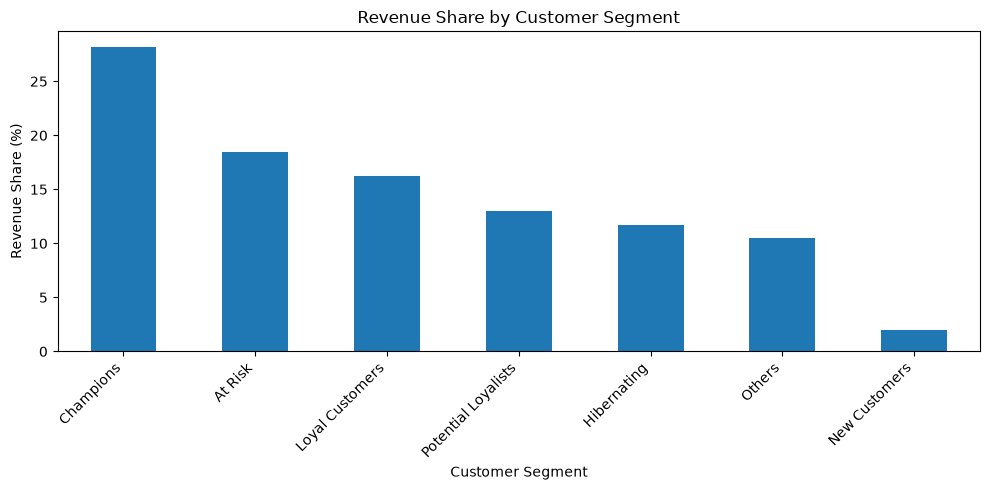

In [61]:
segment_revenue = (
    segment_summary["Revenue_Share_%"]
    .sort_values(ascending=False)
)

segment_revenue.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Revenue Share by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Share (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 9.3 Revenue at Risk

At Risk and Hibernating customers represent customers who show signs of
inactivity. Measuring their combined revenue contribution helps estimate
the scale of the potential retention and reactivation opportunity.

In [62]:
risk_segments = ["At Risk", "Hibernating"]

risk_summary = segment_summary.loc[risk_segments]

risk_customers = risk_summary["Customers"].sum()
risk_sales = risk_summary["Total_Sales"].sum()
risk_revenue_share = risk_summary["Revenue_Share_%"].sum()

print(f"At-Risk + Hibernating Customers: {risk_customers:,}")
print(f"Revenue from At-Risk + Hibernating: ₹{risk_sales:,.2f}")
print(f"Revenue Share: {risk_revenue_share:.2f}%")

At-Risk + Hibernating Customers: 17,253
Revenue from At-Risk + Hibernating: ₹1,238,204,975.09
Revenue Share: 30.13%


### Key Finding — Revenue at Risk

At Risk and Hibernating customers together represent a significant portion
of the customer base and historical revenue.

This highlights a substantial customer reactivation opportunity. However,
the revenue associated with these customers should be treated as
**potential revenue at risk**, rather than guaranteed recoverable revenue,
because the analysis does not measure campaign response or future
purchasing behavior.

### Recommended Actions

1. Prioritize high-value At Risk customers for personalized reactivation.
2. Use purchase history to recommend relevant products.
3. Offer targeted incentives rather than blanket discounts.
4. Test different reactivation campaigns and measure conversion.
5. Use Hibernating customers as a lower-cost secondary reactivation group.

### Revenue at Risk — Key Finding

A total of **17,253 customers** are classified as either At Risk or
Hibernating.

These customers have historically generated approximately **₹1.238B**,
representing **30.13% of total revenue**.

This should be viewed as **potential revenue at risk**, rather than
guaranteed lost revenue, because the analysis does not measure future
purchase behavior or campaign response.

### Recommended Actions

- Prioritize high-value At Risk customers for personalized reactivation.
- Recommend products based on previous purchasing behavior.
- Test targeted incentives instead of applying blanket discounts.
- Measure campaign conversion and recovered revenue.
- Use lower-cost reactivation campaigns for Hibernating customers.

## 10. Product & Category Performance

This section evaluates category and product-level sales, profitability,
order volume, and profit margins to identify the strongest revenue and
profit drivers as well as products requiring attention.

### 10.1 Category Performance

In [63]:
category_summary = (
    df.groupby("Category")
      .agg(
          Sales=("Final_Sales", "sum"),
          Cost=("Cost", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order_ID", "nunique")
      )
      .sort_values("Sales", ascending=False)
)

category_summary["Profit_Margin_%"] = (
    category_summary["Profit"]
    / category_summary["Sales"]
) * 100

category_summary

,Sales,Cost,Profit,Orders,Profit_Margin_%
Category,,,,,
Electronics,"2,825,506,092.64","1,977,939,311.14","847,566,781.50",45032,30.00
Home & Kitchen,"626,663,387.41","438,519,406.30","188,143,981.11",34036,30.02
Fashion,"275,899,279.68","193,317,491.28","82,581,788.40",44821,29.93
Sports,"190,851,766.26","133,756,449.29","57,095,316.97",21789,29.92
Beauty,"127,347,839.74","89,197,798.81","38,150,040.93",26550,29.96
Books,"63,622,465.34","44,510,557.67","19,111,907.67",27772,30.04


In [64]:
category_summary["Sales_Share_%"] = (
    category_summary["Sales"]
    / category_summary["Sales"].sum()
) * 100

category_summary

,Sales,Cost,Profit,Orders,Profit_Margin_%,Sales_Share_%
Category,,,,,,
Electronics,"2,825,506,092.64","1,977,939,311.14","847,566,781.50",45032,30.00,68.75
Home & Kitchen,"626,663,387.41","438,519,406.30","188,143,981.11",34036,30.02,15.25
Fashion,"275,899,279.68","193,317,491.28","82,581,788.40",44821,29.93,6.71
Sports,"190,851,766.26","133,756,449.29","57,095,316.97",21789,29.92,4.64
Beauty,"127,347,839.74","89,197,798.81","38,150,040.93",26550,29.96,3.10
Books,"63,622,465.34","44,510,557.67","19,111,907.67",27772,30.04,1.55


### Category Performance — Key Findings

**Electronics** is the dominant category, generating approximately
₹2.83B in sales and contributing **68.75% of total sales**. It also
generates the highest absolute profit at approximately ₹847.6M.

**Home & Kitchen** is the second-largest category, contributing
**15.25% of total sales** and approximately ₹188.1M in profit.

Together, Electronics and Home & Kitchen account for approximately
**84% of total sales**, indicating significant sales concentration in
these two categories.

Profit margins are highly consistent across categories, ranging from
approximately **29.92% to 30.04%**. Therefore, differences in absolute
profit are primarily driven by sales volume rather than substantial
differences in category-level margin.

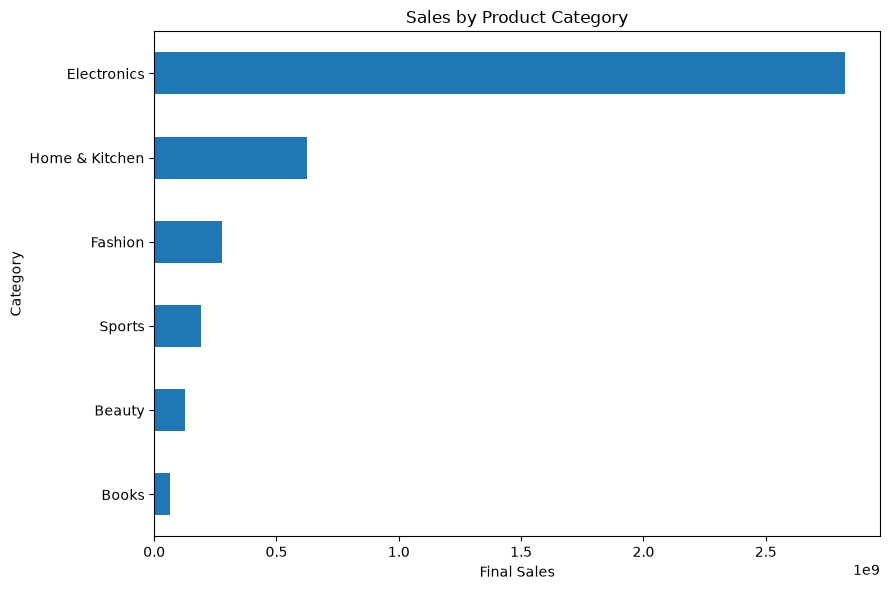

In [65]:
category_summary["Sales"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Sales by Product Category")
plt.xlabel("Final Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

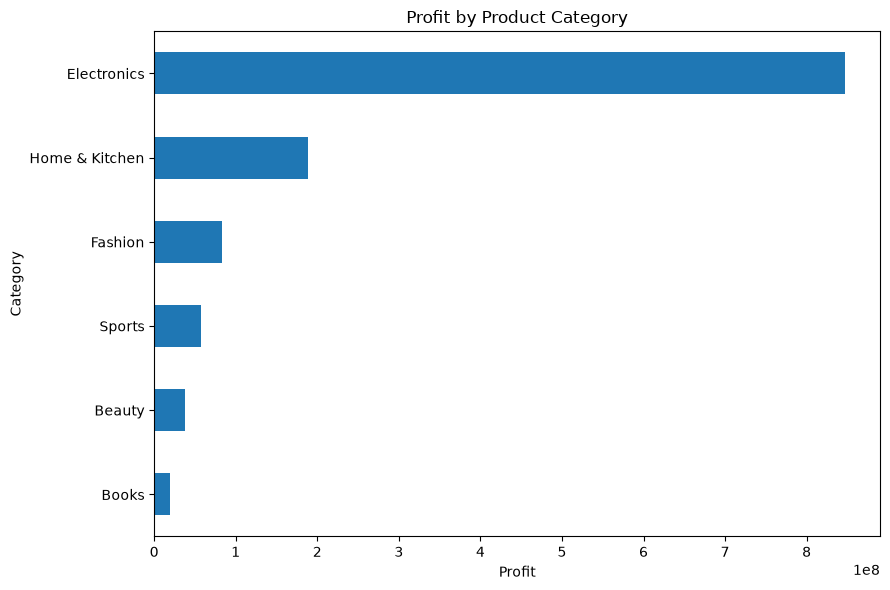

In [66]:
category_summary["Profit"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Profit by Product Category")
plt.xlabel("Profit")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### 10.2 Product-Level Performance

Analyze individual products to identify the highest revenue and profit
contributors and understand which products have the greatest business
impact.

In [67]:
product_summary = (
    df.groupby(
        ["Product_ID", "Product_Name", "Category"]
    )
    .agg(
        Sales=("Final_Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .reset_index()
)

product_summary["Profit_Margin_%"] = (
    product_summary["Profit"]
    / product_summary["Sales"]
) * 100

product_summary = product_summary.sort_values(
    "Sales",
    ascending=False
)

product_summary.head(10)

,Product_ID,Product_Name,Category,Sales,Profit,Orders,Profit_Margin_%
24,25,Product_025,Electronics,"52,494,959.14","15,711,773.99",424,29.93
329,330,Product_330,Electronics,"52,302,130.91","15,612,810.79",406,29.85
186,187,Product_187,Electronics,"49,429,969.35","14,977,771.51",423,30.30
28,29,Product_029,Electronics,"49,149,199.17","14,455,743.98",407,29.41
280,281,Product_281,Electronics,"48,698,497.01","14,560,850.31",400,29.90
359,360,Product_360,Electronics,"46,718,318.09","14,090,157.57",421,30.16
488,489,Product_489,Electronics,"45,973,548.83","13,606,414.92",407,29.60
139,140,Product_140,Electronics,"45,344,855.70","13,616,148.36",393,30.03
225,226,Product_226,Electronics,"45,337,151.95","13,645,897.59",387,30.10
406,407,Product_407,Electronics,"45,005,673.18","13,439,972.92",445,29.86


### Top Products — Key Findings

The top 10 products by sales are all from the **Electronics** category,
reinforcing Electronics as the company's primary revenue driver.

**Product_025** is the highest-selling product, generating approximately
₹52.49M in sales and ₹15.71M in profit.

**Product_407** has the highest order count among the top 10 products,
with 445 orders, although it ranks tenth by sales.

Profit margins across the top products are relatively consistent,
suggesting that sales volume is a more important differentiator than
margin percentage among these products.

### 10.3 Top Products by Profit

In [68]:
top_profit_products = (
    product_summary
    .sort_values("Profit", ascending=False)
    .head(10)
)

top_profit_products

,Product_ID,Product_Name,Category,Sales,Profit,Orders,Profit_Margin_%
24,25,Product_025,Electronics,"52,494,959.14","15,711,773.99",424,29.93
329,330,Product_330,Electronics,"52,302,130.91","15,612,810.79",406,29.85
186,187,Product_187,Electronics,"49,429,969.35","14,977,771.51",423,30.30
280,281,Product_281,Electronics,"48,698,497.01","14,560,850.31",400,29.90
28,29,Product_029,Electronics,"49,149,199.17","14,455,743.98",407,29.41
359,360,Product_360,Electronics,"46,718,318.09","14,090,157.57",421,30.16
142,143,Product_143,Electronics,"44,933,811.99","13,647,573.16",402,30.37
225,226,Product_226,Electronics,"45,337,151.95","13,645,897.59",387,30.10
139,140,Product_140,Electronics,"45,344,855.70","13,616,148.36",393,30.03
488,489,Product_489,Electronics,"45,973,548.83","13,606,414.92",407,29.60


In [69]:
top_margin_products = (
    product_summary
    .sort_values("Profit_Margin_%", ascending=False)
    .head(10)
)

top_margin_products

,Product_ID,Product_Name,Category,Sales,Profit,Orders,Profit_Margin_%
436,437,Product_437,Electronics,"26,878,322.88","8,363,932.62",427,31.12
498,499,Product_499,Fashion,"1,532,352.79","476,084.99",405,31.07
211,212,Product_212,Fashion,"3,478,041.01","1,073,681.12",394,30.87
427,428,Product_428,Electronics,"22,622,172.64","6,975,253.83",431,30.83
295,296,Product_296,Sports,"2,051,643.18","631,882.06",389,30.80
222,223,Product_223,Fashion,"2,294,971.65","706,727.59",401,30.79
397,398,Product_398,Fashion,"750,670.17","230,992.75",409,30.77
400,401,Product_401,Fashion,"1,305,987.27","401,857.73",387,30.77
165,166,Product_166,Home & Kitchen,"12,408,598.64","3,815,703.97",427,30.75
37,38,Product_038,Electronics,"32,820,001.42","10,090,832.16",403,30.75


### Highest-Margin Products — Key Findings

**Product_437** has the highest profit margin at approximately **31.12%**,
with ₹26.88M in sales and ₹8.36M in profit.

Several other products also achieve margins above 30.7%.

The analysis highlights an important distinction between **absolute profit**
and **profit margin**. A product can have a higher margin percentage without
generating the highest total profit.

For example, Product_025 generates approximately ₹15.71M in profit at a
29.93% margin, while Product_437 generates ₹8.36M at a higher 31.12%
margin.

Therefore, product decisions should consider both sales volume and
profitability rather than margin percentage alone.

### 10.4 Product Segmentation

Products are classified using sales performance and profit margin.

The segmentation identifies products that drive revenue, products with
strong margins but lower sales, high-performing "Stars", and products
requiring improvement.

In [70]:
sales_median = product_summary["Sales"].median()
margin_median = product_summary["Profit_Margin_%"].median()

print(f"Median Product Sales: ₹{sales_median:,.2f}")
print(f"Median Product Margin: {margin_median:.2f}%")

Median Product Sales: ₹2,925,708.33
Median Product Margin: 29.97%


In [71]:
def product_segment(row):
    high_sales = row["Sales"] >= sales_median
    high_margin = row["Profit_Margin_%"] >= margin_median

    if high_sales and high_margin:
        return "Stars"
    elif high_sales and not high_margin:
        return "Revenue Drivers"
    elif not high_sales and high_margin:
        return "Margin Opportunities"
    else:
        return "Underperformers"


product_summary["Product_Segment"] = (
    product_summary.apply(product_segment, axis=1)
)

In [72]:
product_summary["Product_Segment"].value_counts()

Product_Segment
Revenue Drivers         131
Margin Opportunities    131
Stars                   119
Underperformers         119
Name: count, dtype: int64

In [73]:
product_segment_summary = (
    product_summary
    .groupby("Product_Segment")
    .agg(
        Products=("Product_ID", "count"),
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Avg_Margin=("Profit_Margin_%", "mean")
    )
)

product_segment_summary["Sales_Share_%"] = (
    product_segment_summary["Total_Sales"]
    / product_segment_summary["Total_Sales"].sum()
) * 100

product_segment_summary["Profit_Share_%"] = (
    product_segment_summary["Total_Profit"]
    / product_segment_summary["Total_Profit"].sum()
) * 100

product_segment_summary

,Products,Total_Sales,Total_Profit,Avg_Margin,Sales_Share_%,Profit_Share_%
Product_Segment,,,,,,
Margin Opportunities,131,"196,914,831.04","59,573,199.26",30.27,4.79,4.83
Revenue Drivers,131,"2,033,222,389.92","604,316,840.40",29.69,49.47,49.03
Stars,119,"1,703,048,010.74","516,370,344.65",30.29,41.44,41.89
Underperformers,119,"176,705,599.38","52,389,432.27",29.66,4.30,4.25


### Product Segmentation — Key Findings

The product portfolio is strongly concentrated in high-performing products.

**Revenue Drivers and Stars together generate 90.91% of total sales and
90.92% of total profit.**

**Stars** contribute 41.44% of sales and 41.89% of profit and have the
highest average margin at 30.29%. These products should be protected and
prioritized.

**Revenue Drivers** generate the largest sales share at 49.47%, but their
average margin is slightly lower at 29.69%. Margin improvement should be
investigated for these products.

**Margin Opportunities** have a relatively strong average margin of
30.27% but contribute only 4.79% of sales, suggesting potential for
careful scaling.

**Underperformers** contribute only 4.30% of sales and have the lowest
average margin at 29.66%, making them candidates for performance review.

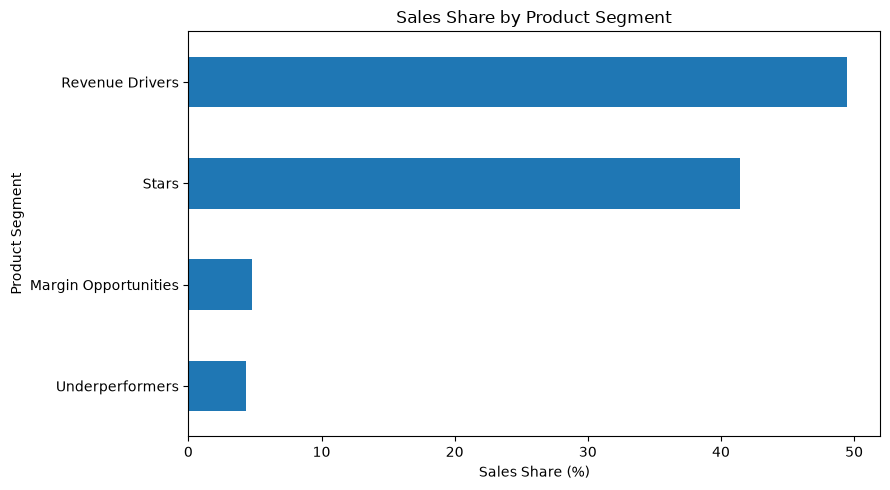

In [74]:
product_segment_summary["Sales_Share_%"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Sales Share by Product Segment")
plt.xlabel("Sales Share (%)")
plt.ylabel("Product Segment")
plt.tight_layout()
plt.show()

## 11. Geographic Performance

Analyze sales, profit, orders, customers, and profit margins across cities
to identify high-performing markets and locations experiencing significant
year-over-year changes.

### 11.1 City-Level Performance

In [75]:
city_summary = (
    df.groupby("City")
      .agg(
          Sales=("Final_Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("Order_ID", "nunique"),
          Customers=("Customer_ID", "nunique")
      )
      .sort_values("Sales", ascending=False)
)

city_summary["Profit_Margin_%"] = (
    city_summary["Profit"]
    / city_summary["Sales"]
) * 100

city_summary

,Sales,Profit,Orders,Customers,Profit_Margin_%
City,,,,,
Lucknow,"290,859,716.34","87,283,599.15",13699,3307,30.01
Chennai,"281,037,032.64","83,945,690.15",13574,3313,29.87
Bengaluru,"280,462,850.19","84,574,590.14",13472,3291,30.16
Nashik,"280,300,633.90","83,929,071.79",13444,3318,29.94
Thane,"279,175,516.78","83,486,126.31",13253,3258,29.90
Nagpur,"276,293,783.05","82,716,749.51",13813,3336,29.94
Hyderabad,"273,001,038.23","82,527,234.26",13263,3254,30.23
Mumbai,"271,252,508.77","81,227,574.41",13234,3291,29.95
Pune,"270,760,225.31","80,395,698.85",13321,3307,29.69


### City Performance — Key Findings

**Lucknow** is the highest-performing city by total sales, generating
approximately ₹290.86M in sales and ₹87.28M in profit.

**Bengaluru** has the highest profit margin among the cities at
approximately **30.16%**, despite ranking third in total sales.

City-level sales are relatively balanced compared with the strong
concentration observed at the category level. The difference between the
highest-sales city (Lucknow) and lowest-sales city (Surat) is approximately
₹28.7M.

This indicates that overall geographic performance is relatively
diversified, although individual cities may still experience significant
year-over-year changes.

### 11.2 City Year-over-Year Sales Change

Compare city-level sales between 2024 and 2025 to identify markets
experiencing significant growth or decline.

In [76]:
city_yoy = (
    df.groupby(["Order_Year", "City"])["Final_Sales"]
      .sum()
      .unstack("Order_Year")
)

city_yoy["Sales_Change"] = (
    city_yoy[2025] - city_yoy[2024]
)

city_yoy["Sales_Change_%"] = (
    city_yoy["Sales_Change"]
    / city_yoy[2024]
) * 100

city_yoy.sort_values(
    "Sales_Change_%",
    ascending=True
)

Order_Year,2024,2025,Sales_Change,Sales_Change_%
City,,,,
Lucknow,"149,747,358.60","141,112,357.74","-8,635,000.86",-5.77
Hyderabad,"140,480,278.78","132,520,759.45","-7,959,519.33",-5.67
Pune,"138,611,445.12","132,148,780.19","-6,462,664.93",-4.66
Jaipur,"137,240,908.93","131,966,059.94","-5,274,848.98",-3.84
Nagpur,"140,039,632.64","136,254,150.41","-3,785,482.24",-2.70
Kolkata,"136,451,271.50","132,796,785.11","-3,654,486.40",-2.68
Ahmedabad,"134,802,889.51","133,086,006.01","-1,716,883.50",-1.27
Delhi,"134,599,159.18","133,073,595.04","-1,525,564.14",-1.13
Indore,"134,694,431.21","135,886,765.56","1,192,334.36",0.89


In [77]:
city_yoy.sort_values(
    "Sales_Change_%",
    ascending=False
)

Order_Year,2024,2025,Sales_Change,Sales_Change_%
City,,,,
Surat,"128,460,741.28","133,688,912.62","5,228,171.34",4.07
Bengaluru,"138,000,802.12","142,462,048.07","4,461,245.95",3.23
Chennai,"138,459,864.08","142,577,168.55","4,117,304.47",2.97
Nashik,"138,215,531.87","142,085,102.03","3,869,570.16",2.80
Thane,"137,857,497.14","141,318,019.64","3,460,522.50",2.51
Mumbai,"134,841,523.45","136,410,985.33","1,569,461.88",1.16
Indore,"134,694,431.21","135,886,765.56","1,192,334.36",0.89
Delhi,"134,599,159.18","133,073,595.04","-1,525,564.14",-1.13
Ahmedabad,"134,802,889.51","133,086,006.01","-1,716,883.50",-1.27


### City YoY Performance — Key Findings

City-level analysis shows a mixed performance between 2024 and 2025.

**Surat** recorded the strongest growth, increasing sales by approximately
₹5.23M (+4.07%). Bengaluru, Chennai, Nashik, and Thane also recorded
positive growth.

On the other hand, **Lucknow** experienced the largest absolute decline,
with sales decreasing by approximately ₹8.64M (-5.77%). Hyderabad and
Pune were the next-largest declining cities by absolute sales change.

This indicates that the overall decline in 2025 was not evenly distributed
across all cities. Some markets continued to grow while others experienced
meaningful declines.

### 11.3 Declining City Root-Cause Analysis

In [78]:
declining_cities = ["Lucknow", "Hyderabad", "Pune"]

city_category_yoy = (
    df[df["City"].isin(declining_cities)]
    .groupby(["City", "Order_Year", "Category"])["Final_Sales"]
    .sum()
    .unstack("Order_Year", fill_value=0)
    .reset_index()
)

city_category_yoy["Sales_Change"] = (
    city_category_yoy[2025] - city_category_yoy[2024]
)

city_category_yoy["Sales_Change_%"] = (
    city_category_yoy["Sales_Change"]
    / city_category_yoy[2024]
) * 100

city_category_yoy.sort_values(
    ["City", "Sales_Change"],
    ascending=[True, True]
)

Order_Year,City,Category,2024,2025,Sales_Change,Sales_Change_%
2,Hyderabad,Electronics,"97,403,855.42","89,186,362.90","-8,217,492.52",-8.44
3,Hyderabad,Fashion,"9,301,975.23","9,081,721.21","-220,254.02",-2.37
4,Hyderabad,Home & Kitchen,"21,663,332.49","21,537,351.09","-125,981.40",-0.58
1,Hyderabad,Books,"2,047,459.99","2,122,131.68","74,671.69",3.65
0,Hyderabad,Beauty,"3,943,143.25","4,110,406.13","167,262.88",4.24
5,Hyderabad,Sports,"6,120,512.40","6,482,786.44","362,274.04",5.92
8,Lucknow,Electronics,"104,853,820.89","96,399,952.81","-8,453,868.08",-8.06
9,Lucknow,Fashion,"10,347,851.43","9,050,418.02","-1,297,433.40",-12.54
7,Lucknow,Books,"2,152,662.68","2,065,852.35","-86,810.33",-4.03
11,Lucknow,Sports,"6,701,352.28","6,921,517.00","220,164.72",3.29


### Declining Cities — Category Root Cause

Category-level analysis shows that **Electronics is the dominant contributor
to sales declines in the three largest declining cities.

- Lucknow Electronics declined by approximately **₹8.45M (-8.06%)**.
- Hyderabad Electronics declined by approximately **₹8.22M (-8.44%)**.
- Pune Electronics declined by approximately **₹6.33M (-6.60%)**.

Other categories experienced smaller declines or, in several cases, growth
that partially offset the Electronics weakness.

This pattern is consistent with the earlier February analysis, where
Electronics was also the largest contributor to the monthly sales decline.

The repeated Electronics weakness across multiple cities suggests that
Electronics performance should be investigated as a broader business
issue rather than treating each city decline as an isolated event.

### 11.4 Electronics Product Decline in Key Markets

In [79]:
key_cities = ["Lucknow", "Hyderabad", "Pune"]

electronics_products = (
    df[
        (df["City"].isin(key_cities)) &
        (df["Category"] == "Electronics")
    ]
    .groupby(
        ["City", "Product_ID", "Product_Name", "Order_Year"]
    )["Final_Sales"]
    .sum()
    .unstack("Order_Year", fill_value=0)
    .reset_index()
)

electronics_products["Sales_Change"] = (
    electronics_products[2025]
    - electronics_products[2024]
)

electronics_products["Sales_Change_%"] = (
    electronics_products["Sales_Change"]
    / electronics_products[2024]
) * 100

electronics_products.sort_values(
    "Sales_Change"
).head(20)

Order_Year,City,Product_ID,Product_Name,2024,2025,Sales_Change,Sales_Change_%
118,Lucknow,26,Product_026,"2,630,364.36","1,326,660.46","-1,303,703.90",-49.56
100,Hyderabad,453,Product_453,"2,323,869.03","1,040,002.59","-1,283,866.44",-55.25
122,Lucknow,38,Product_038,"1,997,390.89","742,779.13","-1,254,611.75",-62.81
36,Hyderabad,144,Product_144,"1,816,308.71","776,199.81","-1,040,108.90",-57.26
198,Lucknow,375,Product_375,"2,426,590.65","1,414,638.84","-1,011,951.81",-41.70
55,Hyderabad,229,Product_229,"1,582,345.80","570,812.95","-1,011,532.85",-63.93
45,Hyderabad,192,Product_192,"1,614,313.39","657,505.19","-956,808.20",-59.27
140,Lucknow,111,Product_111,"1,520,236.20","589,992.18","-930,244.02",-61.19
13,Hyderabad,43,Product_043,"2,279,065.60","1,358,626.50","-920,439.10",-40.39
165,Lucknow,221,Product_221,"1,592,552.79","693,107.39","-899,445.40",-56.48


### Electronics Product-Level Root Cause

Product-level analysis shows that the Electronics decline in Lucknow,
Hyderabad, and Pune is spread across multiple products rather than being
driven by a single product.

Several products experienced sales declines of more than 40%, including
Product_026 in Lucknow (-49.56%), Product_453 in Hyderabad (-55.25%),
Product_038 in Lucknow (-62.81%), and Product_229 in Hyderabad (-63.93%).

This indicates broad weakness across multiple Electronics products in
key declining markets.

The transaction dataset identifies the locations and products associated
with the decline, but it does not provide enough information to determine
whether the underlying causes were inventory availability, competition,
pricing, demand changes, or other operational factors.

## 12. Executive KPI Summary

The following KPIs summarize overall business performance across the
2024–2025 period.

In [80]:
total_sales = df["Final_Sales"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
aov = total_sales / total_orders

total_profit = df["Profit"].sum()
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value: ₹{aov:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

Total Sales: ₹4,109,890,831.08
Total Orders: 200,000
Total Customers: 49,054
Average Order Value: ₹20,549.45
Total Profit: ₹1,232,649,816.58
Overall Profit Margin: 29.99%


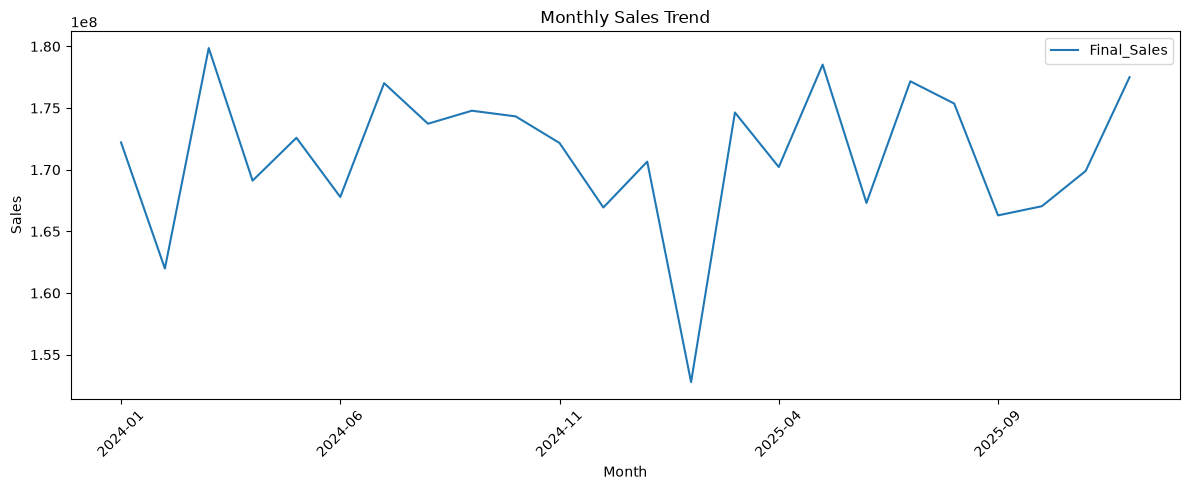

In [81]:
monthly_sales = (
    df.groupby(["Order_Year", "Order_Month"])["Final_Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Period"] = (
    monthly_sales["Order_Year"].astype(str)
    + "-"
    + monthly_sales["Order_Month"].astype(str).str.zfill(2)
)

monthly_sales.plot(
    x="Period",
    y="Final_Sales",
    kind="line",
    figsize=(12, 5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

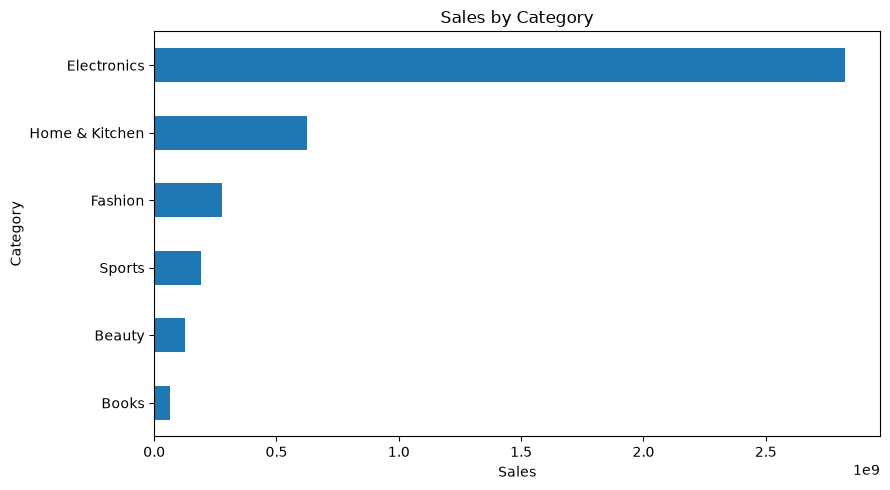

In [82]:
category_summary["Sales"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Sales by Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

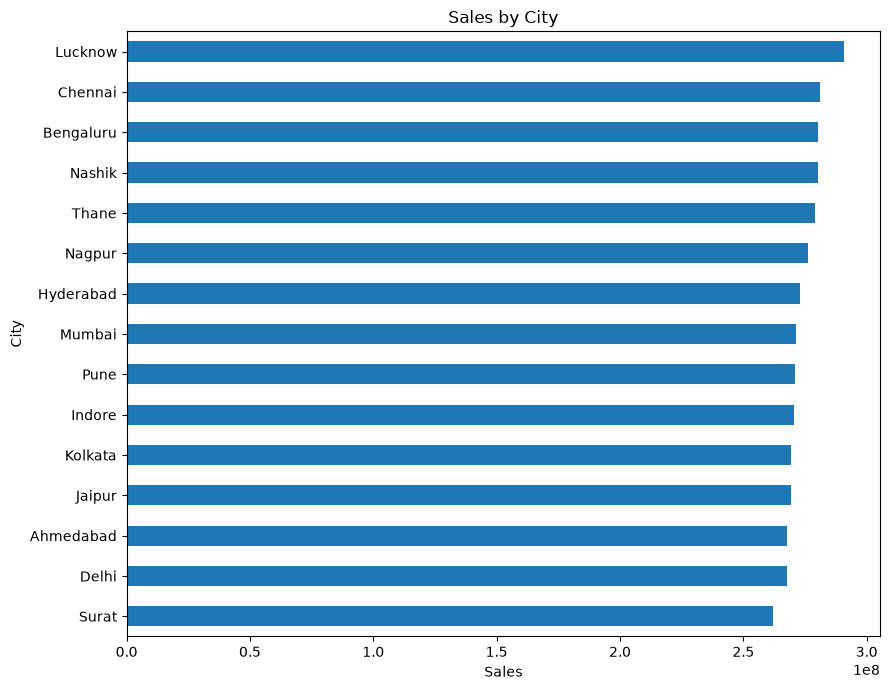

In [83]:
city_summary["Sales"].sort_values().plot(
    kind="barh",
    figsize=(9, 7)
)

plt.title("Sales by City")
plt.xlabel("Sales")
plt.ylabel("City")
plt.tight_layout()
plt.show()

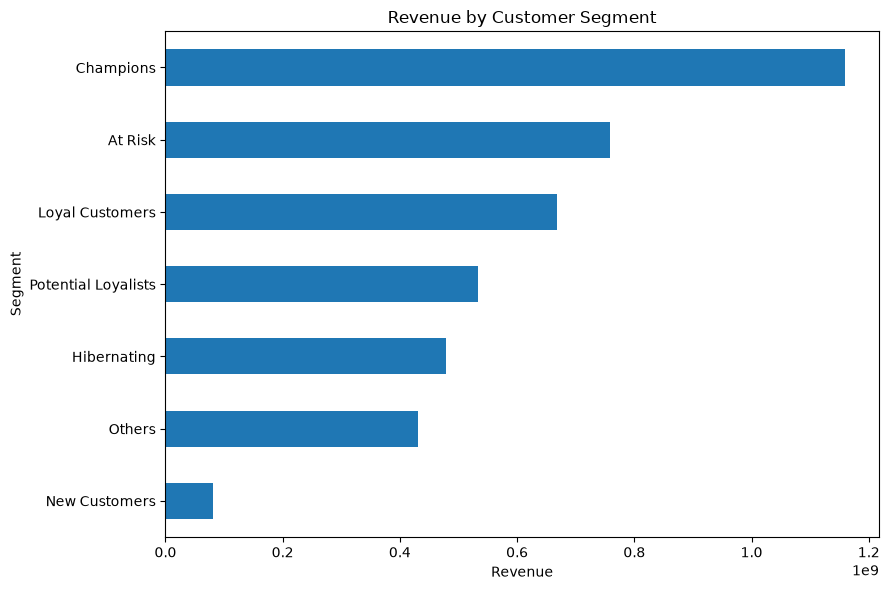

In [84]:
segment_summary["Total_Sales"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

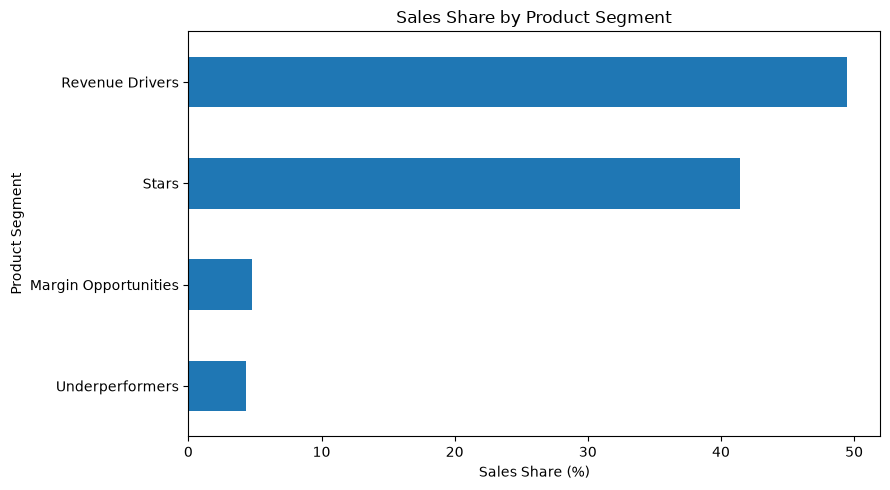

In [85]:
product_segment_summary["Sales_Share_%"].sort_values().plot(
    kind="barh",
    figsize=(9, 5)
)

plt.title("Sales Share by Product Segment")
plt.xlabel("Sales Share (%)")
plt.ylabel("Product Segment")
plt.tight_layout()
plt.show()

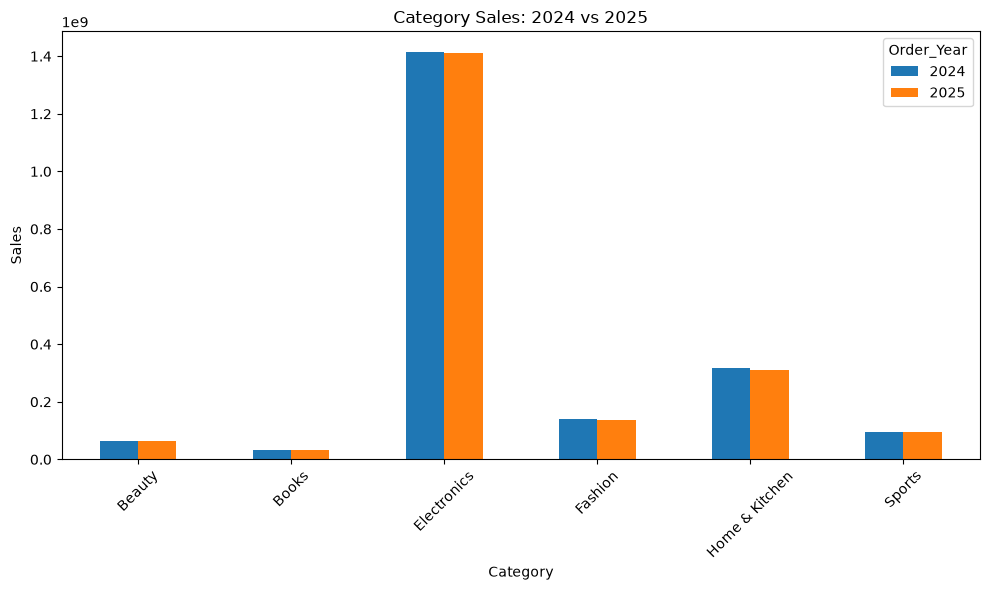

In [86]:
category_year = (
    df.groupby(["Category", "Order_Year"])["Final_Sales"]
      .sum()
      .unstack()
)

category_year.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Category Sales: 2024 vs 2025")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 13. Executive Summary & Business Recommendations

## Key Findings

### 1. Overall Sales Decline

2025 sales declined by approximately **0.73%** compared with 2024.
Although the overall decline is relatively small, several months and
markets experienced significant weakness.

### 2. Electronics is the Main Revenue Driver and Risk

Electronics contributes approximately **68.75% of total sales** and is
therefore the company's primary revenue engine.

However, Electronics also drove the major sales declines identified in
the analysis.

### 3. February 2025 Decline

February 2025 experienced a **5.69% YoY sales decline**, equivalent to
approximately **₹9.21M**.

Electronics contributed approximately **₹7.68M** of this decline.

### 4. Geographic Weakness

Lucknow, Hyderabad, and Pune were among the largest declining cities.
Electronics was the dominant declining category in all three markets.

### 5. Customer Retention Opportunity

Repeat customers represent **92.50% of customers** and generate
**98.10% of total sales**.

At Risk and Hibernating customers account for **17,253 customers** and
approximately **30.13% of historical revenue**, representing a major
potential reactivation opportunity.

### 6. Product Portfolio

Revenue Drivers and Stars account for approximately **90.91% of sales**
and **90.92% of profit**, showing that the business is strongly supported
by high-performing products.

## Business Recommendations

### Recommendation 1 — Protect Electronics Performance

Because Electronics contributes 68.75% of sales, management should
closely monitor Electronics demand, inventory availability, pricing,
and product-level performance.

### Recommendation 2 — Investigate Declining Markets

Prioritize Lucknow, Hyderabad, and Pune for deeper operational
investigation because these markets experienced significant declines,
largely driven by Electronics.

### Recommendation 3 — Reactivate At Risk Customers

Prioritize high-value At Risk customers with personalized offers,
product recommendations, and targeted reactivation campaigns.

### Recommendation 4 — Develop Potential Loyalists

Use cross-selling, product recommendations, bundles, and loyalty
incentives to increase purchase frequency among Potential Loyalists.

### Recommendation 5 — Protect Champions

Champions generate 28.21% of revenue. Retention programs, exclusive
benefits, and personalized experiences should be used to protect this
high-value segment.

### Recommendation 6 — Review Underperforming Products

Underperforming products contribute only 4.30% of sales. Management
should review their demand, pricing, assortment, and inventory
allocation before committing additional resources.

### Recommendation 7 — Investigate Product Availability

Several Electronics products experienced substantial year-over-year
declines or disappeared from specific markets. Additional inventory,
availability, and operational data should be analyzed to determine the
underlying causes.

# E-Commerce Sales & Customer Analytics

### 2024–2025 Business Performance Analysis

**Objective:** Analyze sales, customers, products, profitability, and
geographic performance to identify business trends, risks, and growth
opportunities.

**Dataset:** 200,000 transactions | 49,054 customers | 2024–2025

## Executive Summary

This project analyzes 200,000 e-commerce transactions across 2024 and
2025 to evaluate business performance, customer behavior, product
profitability, and geographic trends.

### Key Findings

- Total sales reached approximately **₹4.11B** with an overall profit
  margin of approximately **29.99%**.
- 2025 sales declined by approximately **0.73%** compared with 2024.
- **Electronics** is the dominant category, contributing approximately
  **68.75% of total sales**.
- February 2025 recorded the largest monthly sales decline at
  approximately **-5.69%**.
- Repeat customers represent **92.50% of customers** and contribute
  **98.10% of total sales**.
- **17,253 At Risk and Hibernating customers** account for approximately
  **30.13% of historical revenue**, creating a significant potential
  reactivation opportunity.
- Lucknow, Hyderabad, and Pune experienced significant year-over-year
  declines, with Electronics being the dominant declining category.
- Stars and Revenue Drivers account for approximately **90.91% of sales**
  and **90.92% of profit**.

# 1. Project Overview
# 2. Data Loading & Data Quality
# 3. Overall Business Performance
# 4. Sales Trend Analysis
# 5. Root-Cause Analysis
# 6. Customer Analysis
# 7. RFM Customer Segmentation
# 8. Product & Profitability Analysis
# 9. Geographic Analysis
# 10. Executive Findings
# 11. Business Recommendations
# 12. Conclusion

# 12. Conclusion

The analysis shows that the business remains highly profitable, with
approximately ₹4.11B in sales and a 29.99% overall profit margin.

However, 2025 experienced a modest 0.73% decline in sales. The decline
was concentrated in specific months, markets, and primarily the
Electronics category.

Customer analysis shows strong repeat purchasing behavior, with repeat
customers generating 98.10% of revenue. At the same time, the At Risk and
Hibernating segments represent a significant potential reactivation
opportunity.

Product analysis shows that the business is strongly supported by Stars
and Revenue Drivers, which together account for more than 90% of sales
and profit.

Overall, the analysis highlights three major priorities:

1. **Protect Electronics performance**
2. **Reactivate valuable inactive customers**
3. **Investigate declining geographic markets and products**

Further operational data such as inventory availability, pricing,
competition, and marketing activity would be required to determine the
underlying causes behind the observed sales declines.